In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
superstore = pd.read_excel('/content/US Superstore data.xls')
superstore.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
print("Dataset Shape:", superstore.shape)
print("\nColumn Names:")
print(superstore.columns.tolist())

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:
superstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [9]:
superstore.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [10]:
print("Duplicate rows:", superstore.duplicated().sum())

Duplicate rows: 0


In [11]:
superstore.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Which states have the most sales?**

In [18]:
state_sales = (
    superstore.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Sales': 'Total Sales'})
)

print(state_sales.head(10))

          State  Total Sales
0    California  457687.6315
1      New York  310876.2710
2         Texas  170188.0458
3    Washington  138641.2700
4  Pennsylvania  116511.9140
5       Florida   89473.7080
6      Illinois   80166.1010
7          Ohio   78258.1360
8      Michigan   76269.6140
9      Virginia   70636.7200


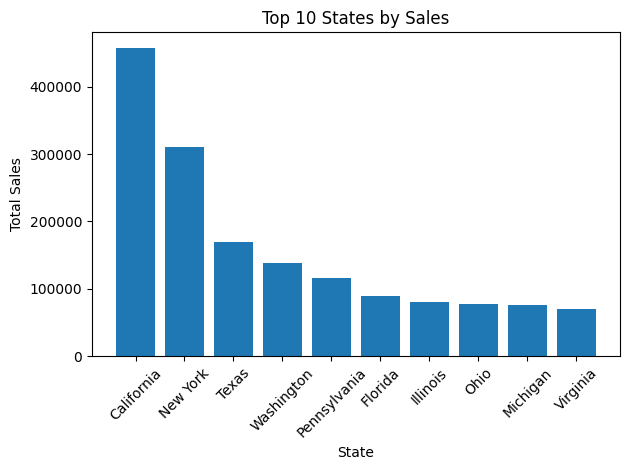

In [21]:
# aggregate
state_sales = superstore.groupby("State", as_index=False)["Sales"].sum()

# sort and take top 10
top_states = state_sales.sort_values(by="Sales", ascending=False).head(10)

# plot
plt.figure()
plt.bar(top_states["State"], top_states["Sales"])

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

# rotate for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

California dominates with ~$457K in total sales — more than 1.5x the second-place state. The top 3 states (California, New York, Texas) together account for roughly 42% of all revenue, which is a classic power-law distribution common in retail data. The remaining 46 states split the other 58%.
A few things worth digging into from here: whether high-sales states also have high profit margins (discounting in Texas is notably aggressive), and whether the concentration risk in California and New York is something to monitor strategically.

What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)

In [22]:
# group by State and calculate Sales + Profit
state_summary = superstore.groupby("State")[["Sales", "Profit"]].sum()

# filter only New York and California
comparison = state_summary.loc[["New York", "California"]]

print(comparison)

                  Sales      Profit
State                              
New York    310876.2710  74038.5486
California  457687.6315  76381.3871


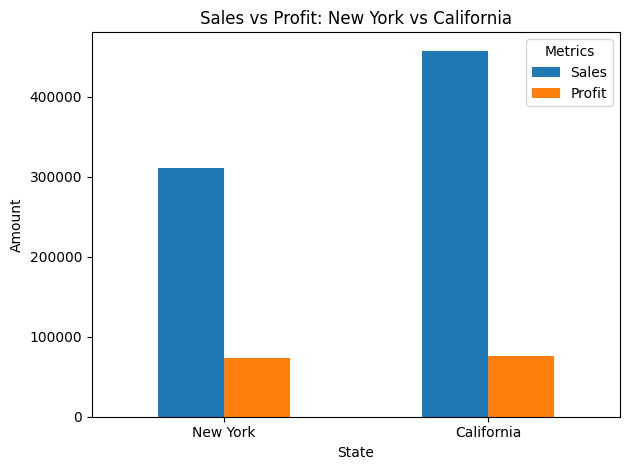

In [23]:
# plot side-by-side bars
comparison.plot(kind="bar")

plt.title("Sales vs Profit: New York vs California")
plt.xlabel("State")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()

Who is an outstanding customer in New York?

In [24]:
# filter only New York
ny_df = superstore[superstore["State"] == "New York"]

# group by customer
customer_summary = ny_df.groupby("Customer Name")[["Sales", "Profit"]].sum()

# sort by Sales (you can also sort by Profit)
top_customer = customer_summary.sort_values(by="Sales", ascending=False)

print(top_customer.head())

                      Sales     Profit
Customer Name                         
Tom Ashbrook      13723.498  4599.2073
Peter Fuller       7678.228   543.2819
Seth Vernon        7359.918  1571.7964
Tom Boeckenhauer   6999.960  2239.9872
Greg Tran          6712.744   774.7935


In [25]:
outstanding_customer = top_customer.head(1)
print(outstanding_customer)

                   Sales     Profit
Customer Name                      
Tom Ashbrook   13723.498  4599.2073


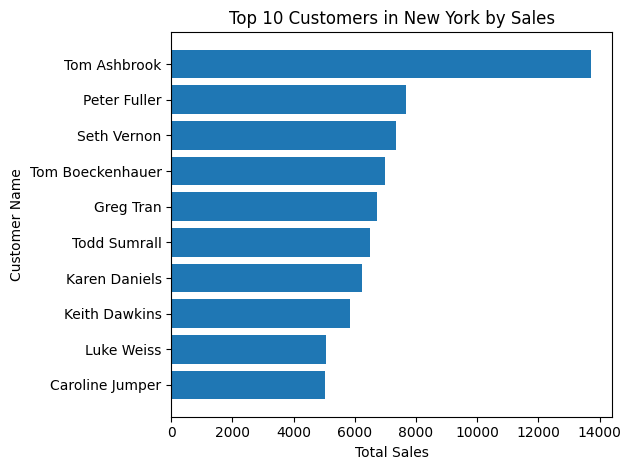

In [26]:
top10_customers = top_customer.head(10)

plt.figure()
plt.barh(top10_customers.index, top10_customers["Sales"])

plt.title("Top 10 Customers in New York by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

Are there any differences among states in profitability?

In [27]:
# aggregate
state_profitability = superstore.groupby("State")[["Sales", "Profit"]].sum()

# calculate profit margin
state_profitability["Profit_Margin"] = state_profitability["Profit"] / state_profitability["Sales"]

# sort by profitability
state_profitability = state_profitability.sort_values(by="Profit_Margin", ascending=False)

print(state_profitability.head())

                          Sales      Profit  Profit_Margin
State                                                     
District of Columbia   2865.020   1059.5893       0.369837
Delaware              27451.069   9977.3748       0.363460
Minnesota             29863.150  10823.1874       0.362426
Maine                  1270.530    454.4862       0.357714
Arkansas              11678.130   4008.6871       0.343264


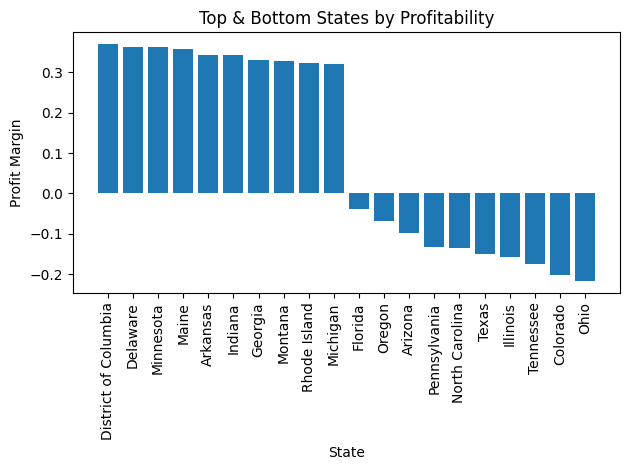

In [28]:
# combine top 10 and bottom 10
top_bottom = pd.concat([
    state_profitability.head(10),
    state_profitability.tail(10)
])

plt.figure()
plt.bar(top_bottom.index, top_bottom["Profit_Margin"])

plt.title("Top & Bottom States by Profitability")
plt.xlabel("State")
plt.ylabel("Profit Margin")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)

In [30]:
# group by customer
customer_profit = superstore.groupby("Customer Name")["Profit"].sum().reset_index()

# sort customers by profit (descending)
customer_profit = customer_profit.sort_values(by="Profit", ascending=False)

In [31]:
# total profit
total_profit = customer_profit["Profit"].sum()

# cumulative profit
customer_profit["Cumulative_Profit"] = customer_profit["Profit"].cumsum()

# cumulative percentage
customer_profit["Cumulative_%"] = customer_profit["Cumulative_Profit"] / total_profit

In [33]:
# number of customers
n_customers = len(customer_profit)

# top 20%
top_20_count = int(0.2 * n_customers)

top_20_customers = customer_profit.head(top_20_count)

# profit contribution of top 20%
top_20_profit_share = top_20_customers["Profit"].sum() / total_profit

print(f"Top 20% customers contribute: {top_20_profit_share:.2%} of total profit")

Top 20% customers contribute: 81.43% of total profit


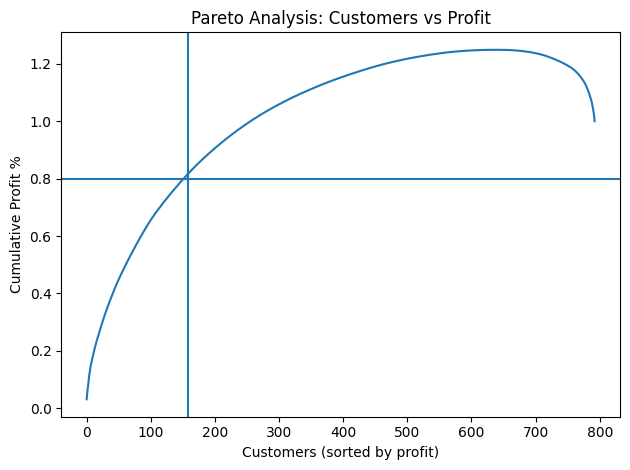

In [34]:
plt.figure()

# cumulative %
plt.plot(customer_profit["Cumulative_%"].values)

# 80% reference line
plt.axhline(0.8)

# 20% reference line
plt.axvline(top_20_count)

plt.title("Pareto Analysis: Customers vs Profit")
plt.xlabel("Customers (sorted by profit)")
plt.ylabel("Cumulative Profit %")

plt.tight_layout()
plt.show()

What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

In [35]:
# group by City
city_summary = superstore.groupby("City")[["Sales", "Profit"]].sum().reset_index()

# calculate profit margin
city_summary["Profit_Margin"] = city_summary["Profit"] / city_summary["Sales"]
top20_sales = city_summary.sort_values(by="Sales", ascending=False).head(20)
print(top20_sales)

              City        Sales      Profit  Profit_Margin
329  New York City  256368.1610  62036.9837       0.241984
266    Los Angeles  175851.3410  30440.7579       0.173105
452        Seattle  119540.7420  29156.0967       0.243901
438  San Francisco  112669.0920  17507.3854       0.155388
374   Philadelphia  109077.0130 -13837.7674      -0.126862
207        Houston   64504.7604 -10153.5485      -0.157408
80         Chicago   48539.5410  -6654.5688      -0.137096
437      San Diego   47521.0290   6377.1960       0.134197
216   Jacksonville   44713.1830  -2323.8350      -0.051972
464    Springfield   43054.3420   6200.6974       0.144020
123        Detroit   42446.9440  13181.7908       0.310547
94        Columbus   38706.2430   5897.1013       0.152355
330         Newark   28576.1190   5793.7588       0.202748
93        Columbia   25283.3240   5606.1167       0.221732
233      Lafayette   25036.2000  10018.3876       0.400156
215        Jackson   24963.8580   7581.6828       0.3037

In [36]:
top20_profit = city_summary.sort_values(by="Profit", ascending=False).head(20)
print(top20_profit)

              City       Sales      Profit  Profit_Margin
329  New York City  256368.161  62036.9837       0.241984
266    Los Angeles  175851.341  30440.7579       0.173105
452        Seattle  119540.742  29156.0967       0.243901
438  San Francisco  112669.092  17507.3854       0.155388
123        Detroit   42446.944  13181.7908       0.310547
233      Lafayette   25036.200  10018.3876       0.400156
215        Jackson   24963.858   7581.6828       0.303706
21         Atlanta   17197.840   6993.6629       0.406659
300    Minneapolis   16870.540   6824.5846       0.404527
437      San Diego   47521.029   6377.1960       0.134197
464    Springfield   43054.342   6200.6974       0.144020
94        Columbus   38706.243   5897.1013       0.152355
330         Newark   28576.119   5793.7588       0.202748
93        Columbia   25283.324   5606.1167       0.221732
407       Richmond   18137.930   5567.2486       0.306940
390     Providence   15980.650   5505.6569       0.344520
194      Hende

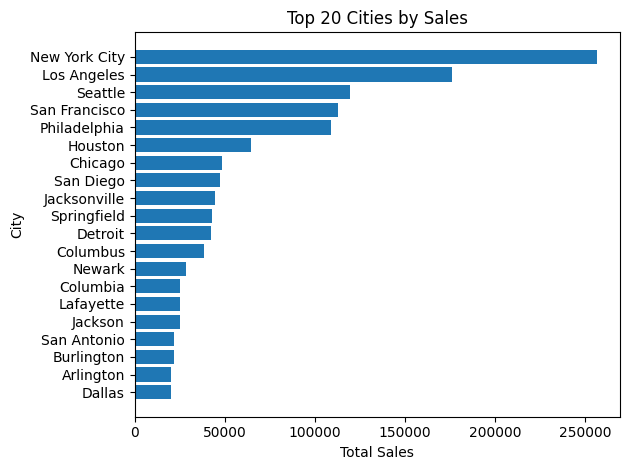

In [37]:
plt.figure()
plt.barh(top20_sales["City"], top20_sales["Sales"])

plt.title("Top 20 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

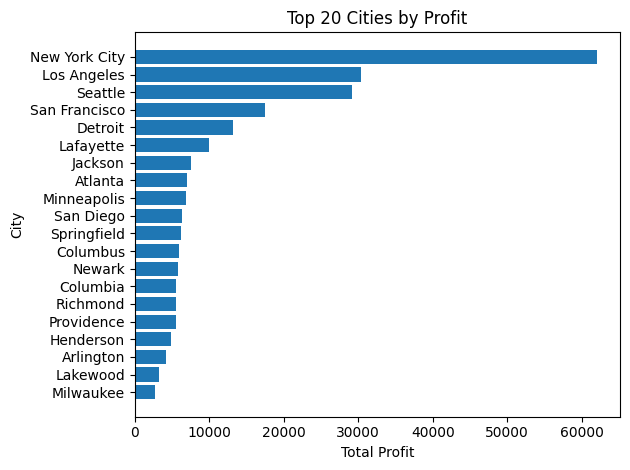

In [38]:
plt.figure()
plt.barh(top20_profit["City"], top20_profit["Profit"])

plt.title("Top 20 Cities by Profit")
plt.xlabel("Total Profit")
plt.ylabel("City")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
# profitability for top sales cities
top_sales_profitability = top20_sales.sort_values(by="Profit_Margin", ascending=False)

print(top_sales_profitability[["City", "Sales", "Profit", "Profit_Margin"]])

              City        Sales      Profit  Profit_Margin
233      Lafayette   25036.2000  10018.3876       0.400156
123        Detroit   42446.9440  13181.7908       0.310547
215        Jackson   24963.8580   7581.6828       0.303706
452        Seattle  119540.7420  29156.0967       0.243901
329  New York City  256368.1610  62036.9837       0.241984
93        Columbia   25283.3240   5606.1167       0.221732
16       Arlington   20214.5320   4169.6969       0.206272
330         Newark   28576.1190   5793.7588       0.202748
266    Los Angeles  175851.3410  30440.7579       0.173105
438  San Francisco  112669.0920  17507.3854       0.155388
94        Columbus   38706.2430   5897.1013       0.152355
464    Springfield   43054.3420   6200.6974       0.144020
437      San Diego   47521.0290   6377.1960       0.134197
216   Jacksonville   44713.1830  -2323.8350      -0.051972
374   Philadelphia  109077.0130 -13837.7674      -0.126862
80         Chicago   48539.5410  -6654.5688      -0.1370

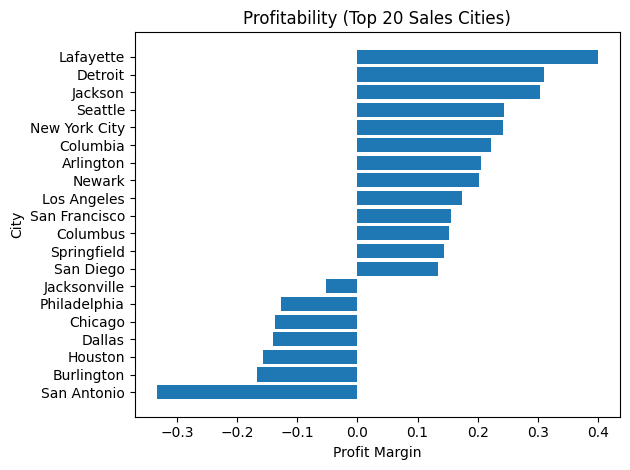

In [40]:
plt.figure()
plt.barh(top_sales_profitability["City"], top_sales_profitability["Profit_Margin"])

plt.title("Profitability (Top 20 Sales Cities)")
plt.xlabel("Profit Margin")
plt.ylabel("City")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

What are the Top 20 customers by Sales?

In [41]:
# group by customer and sum sales
customer_sales = superstore.groupby("Customer Name")["Sales"].sum().reset_index()

# sort descending
customer_sales = customer_sales.sort_values(by="Sales", ascending=False)

print(customer_sales.head(20))

          Customer Name      Sales
686         Sean Miller  25043.050
730        Tamara Chand  19052.218
622        Raymond Buch  15117.339
757        Tom Ashbrook  14595.620
6         Adrian Barton  14473.571
441        Ken Lonsdale  14175.229
671        Sanjit Chand  14142.334
334        Hunter Lopez  12873.298
672        Sanjit Engle  12209.438
156  Christopher Conant  12129.072
756        Todd Sumrall  11891.751
312           Greg Tran  11820.120
75         Becky Martin  11789.630
689         Seth Vernon  11470.950
132     Caroline Jumper  11164.974
169         Clay Ludtke  10880.546
486       Maria Etezadi  10663.728
417      Karen Ferguson  10604.266
90         Bill Shonely  10501.653
249        Edward Hooks  10310.880


In [43]:
top20_customers = customer_sales.head(20)

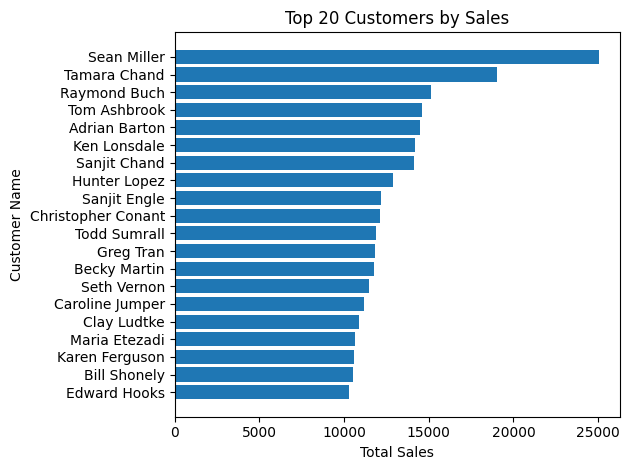

In [44]:
plt.figure()
plt.barh(top20_customers["Customer Name"], top20_customers["Sales"])

plt.title("Top 20 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")

# highest on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

In [46]:
# aggregate sales per customer
customer_sales = superstore.groupby("Customer Name")["Sales"].sum().reset_index()

# sort descending
customer_sales = customer_sales.sort_values(by="Sales", ascending=False)

# total sales
total_sales = customer_sales["Sales"].sum()

# cumulative sales
customer_sales["Cumulative_Sales"] = customer_sales["Sales"].cumsum()

# cumulative percentage
customer_sales["Cumulative_%"] = customer_sales["Cumulative_Sales"] / total_sales

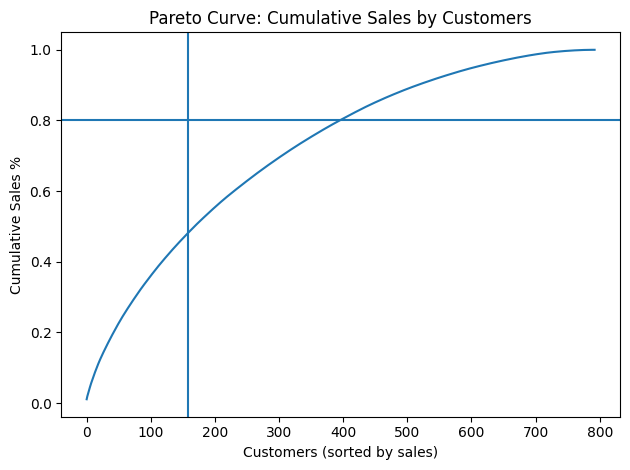

In [47]:
plt.figure()

# cumulative curve
plt.plot(customer_sales["Cumulative_%"].values)

# 80% reference line
plt.axhline(0.8)

# 20% customers line
top_20_count = int(0.2 * len(customer_sales))
plt.axvline(top_20_count)

plt.title("Pareto Curve: Cumulative Sales by Customers")
plt.xlabel("Customers (sorted by sales)")
plt.ylabel("Cumulative Sales %")

plt.tight_layout()
plt.show()

Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

States like California / New York (typically) generate both high sales and profit, making them ideal for scaling efforts. Some high-revenue states underperform in profitability, indicating inefficient discounting or high operational costs.
Based on the analysis, I recommend prioritizing states and cities that combine high sales and strong profitability, as they offer the best return on marketing investment. Additionally, high-sales but low-profit regions should be optimized rather than scaled, while high-margin but underdeveloped areas represent growth opportunities. This segmented approach ensures efficient allocation of marketing resources and maximizes overall profitability.